# 10 — Protein Baseline Models (Pfam Family Classification)

This notebook trains and evaluates traditional baseline ML models for **Pfam family classification** using the engineered features produced in:

`09_protein_baseline_features.ipynb`

## Task
- **Multi-class classification**: predict `family` (Pfam ID like `PF13853`) from engineered protein features.

## Inputs
- `data/processed/protein_features_baseline_top{N_FAM}_per{PER_FAM}.csv`

## Outputs
- Cross-validation results: `reports/protein_baseline_cv_results_top{N_FAM}_per{PER_FAM}.csv`
- Test results: `reports/protein_baseline_test_results_top{N_FAM}_per{PER_FAM}.csv`
- Saved models: `models/protein/baselines/*.pkl`
- Confusion matrices: `reports/figures/cm_*.png`
- Summary JSON: `reports/protein_baseline_models_summary_top{N_FAM}_per{PER_FAM}.json`

## Models included
- Logistic Regression (multinomial, scaled)
- Linear SVM (calibrated probabilities, scaled)
- Random Forest
- Gradient Boosting
- XGBoost (optional, if installed)

## Notes
- XGBoost requires the target labels to be encoded as integers `0..K-1`. This notebook uses `LabelEncoder` to fix that.

In [8]:
from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import yaml
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

warnings.filterwarnings("ignore")

## Optional: install XGBoost

If you want to include XGBoost in this notebook, install it into your current environment, then restart the kernel.

### Conda (recommended)
```bash
conda install -c conda-forge xgboost

In [9]:
ROOT = Path.cwd().parents[0]
DATA = ROOT / "data"
PROCESSED = DATA / "processed"
REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures"
CONFIGS = ROOT / "configs"
MODELS_DIR = ROOT / "models" / "protein" / "baselines"

for p in [REPORTS, FIGURES, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

cfg_path = CONFIGS / "config.yaml"
assert cfg_path.exists(), f"Missing config: {cfg_path}"

with open(cfg_path, "r") as f:
    cfg = yaml.safe_load(f)

SEED = int(cfg["project"]["random_seed"])
N_FAM = int(cfg["protein"]["n_families"])
PER_FAM = int(cfg["protein"]["per_family"])

(SEED, N_FAM, PER_FAM, str(MODELS_DIR))

(42,
 10,
 400,
 '/Users/saturnine/Projects/bio-seq-lm-capstone/models/protein/baselines')

## Load the baseline feature dataset

This file should be produced by `09_protein_baseline_features.ipynb`.

In [10]:
feat_path = PROCESSED / f"protein_features_baseline_top{N_FAM}_per{PER_FAM}.csv"
assert feat_path.exists(), f"Missing features file: {feat_path}"

df = pd.read_csv(feat_path)
df.shape, df.head(2)

((2293, 178),
   accession   family  seq_len    frac_A    frac_C    frac_D    frac_E  \
 0    Q96RD1  PF13853      312  0.044872  0.032051  0.028846  0.016026   
 1    Q9H210  PF13853      308  0.068182  0.029221  0.022727  0.016234   
 
      frac_F    frac_G    frac_H  ...  red7_di_FE  red7_di_FF  red7_di_FG  \
 0  0.096154  0.025641  0.019231  ...    0.009646    0.003215         0.0   
 1  0.058442  0.042208  0.022727  ...    0.006515    0.000000         0.0   
 
    red7_di_GA  red7_di_GB  red7_di_GC  red7_di_GD  red7_di_GE  red7_di_GF  \
 0    0.003215    0.009646    0.009646    0.000000    0.006431    0.003215   
 1    0.013029    0.003257    0.003257    0.006515    0.000000    0.003257   
 
    red7_di_GG  
 0         0.0  
 1         0.0  
 
 [2 rows x 178 columns])

## Sanity checks

Checks performed:
- required columns exist
- no missing values
- label distribution looks reasonable
- the only non-numeric columns are identifiers (`accession`) and label (`family`)

In [11]:
required = ["accession", "family"]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Missing required columns: {missing}"

total_na = int(df.isna().sum().sum())
assert total_na == 0, f"Found missing values in table (total NA={total_na})"

dup_accessions = int(df["accession"].duplicated().sum())
dup_acc_family = int(df.duplicated(subset=["accession", "family"]).sum())

print("Rows:", df.shape[0])
print("Features columns:", df.shape[1])
print("Duplicate accessions:", dup_accessions)
print("Duplicate (accession,family):", dup_acc_family)
print("\nLabel counts:\n", df["family"].value_counts())

obj_cols = df.select_dtypes(include="object").columns.tolist()
assert set(obj_cols).issubset({"accession", "family"}), f"Unexpected non-numeric columns: {obj_cols}"
print("\nObject columns:", obj_cols)

Rows: 2293
Features columns: 178
Duplicate accessions: 0
Duplicate (accession,family): 0

Label counts:
 family
PF13853    400
PF01352    350
PF07686    309
PF00001    287
PF00069    203
PF00096    194
PF00046    187
PF00071    125
PF00076    121
PF12796    117
Name: count, dtype: int64

Object columns: ['accession', 'family']


## Build `X` and `y` (with LabelEncoder)

- `y_raw` is `family` as strings (`PFxxxxx`)
- `y` is integer-encoded class ids required by XGBoost multi-class and convenient for sklearn
- `LabelEncoder` mapping is stored inside each saved `.pkl` file so predictions can be decoded later

In [12]:
y_raw = df["family"].astype(str).values

X_df = df.drop(columns=["accession", "family"]).copy()
assert all(np.issubdtype(dt, np.number) for dt in X_df.dtypes), "X contains non-numeric columns"

X = X_df.values.astype(np.float32)

le = LabelEncoder()
y = le.fit_transform(y_raw).astype(np.int64)

n_classes = int(len(le.classes_))

print("X shape:", X.shape)
print("y shape:", y.shape)
print("n_classes:", n_classes)
print("Classes:", le.classes_.tolist())

X shape: (2293, 176)
y shape: (2293,)
n_classes: 10
Classes: ['PF00001', 'PF00046', 'PF00069', 'PF00071', 'PF00076', 'PF00096', 'PF01352', 'PF07686', 'PF12796', 'PF13853']


## Train/test split

We keep a stratified 80/20 split so the test set is balanced across families.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train label counts:", np.bincount(y_train))
print("Test label counts:", np.bincount(y_test))

Train: (1834, 176) Test: (459, 176)
Train label counts: [229 150 162 100  97 155 280 247  94 320]
Test label counts: [58 37 41 25 24 39 70 62 23 80]


## Define baseline models

Notes:
- Linear models use a scaler in a Pipeline.
- Linear SVM is wrapped with `CalibratedClassifierCV` so we can get stable probability estimates later if needed.
- Tree models do not require scaling.
- XGBoost is included if it is installed.

In [14]:
models = {}

models["logreg"] = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=4000,
        random_state=SEED
    ))
])

models["linear_svm_calibrated"] = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", CalibratedClassifierCV(
        estimator=LinearSVC(random_state=SEED),
        method="sigmoid",
        cv=3
    ))
])

models["random_forest"] = RandomForestClassifier(
    n_estimators=500,
    random_state=SEED,
    n_jobs=-1
)

models["grad_boost"] = GradientBoostingClassifier(random_state=SEED)

xgb_available = False
xgb_reason = None
try:
    import xgboost as xgb
    xgb_available = True
except Exception as e:
    xgb_reason = repr(e)

if xgb_available:
    models["xgboost"] = xgb.XGBClassifier(
        n_estimators=600,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=n_classes,
        eval_metric="mlogloss",
        random_state=SEED,
        n_jobs=-1
    )
else:
    print("XGBoost not available (skipping):", xgb_reason)

list(models.keys())

['logreg', 'linear_svm_calibrated', 'random_forest', 'grad_boost', 'xgboost']

## Cross-validation on training set

We use StratifiedKFold (5 folds) and report:
- accuracy
- precision (weighted)
- recall (weighted)
- f1 (weighted)

Weighted metrics are appropriate when class sizes are not perfectly identical.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    "accuracy": "accuracy",
    "precision_w": "precision_weighted",
    "recall_w": "recall_weighted",
    "f1_w": "f1_weighted",
}

rows = []
for name, clf in models.items():
    t0 = time.time()
    scores = cross_validate(
        clf,
        X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise"
    )
    rows.append({
        "model": name,
        "accuracy_mean": float(np.mean(scores["test_accuracy"])),
        "accuracy_std": float(np.std(scores["test_accuracy"])),
        "precision_w_mean": float(np.mean(scores["test_precision_w"])),
        "precision_w_std": float(np.std(scores["test_precision_w"])),
        "recall_w_mean": float(np.mean(scores["test_recall_w"])),
        "recall_w_std": float(np.std(scores["test_recall_w"])),
        "f1_w_mean": float(np.mean(scores["test_f1_w"])),
        "f1_w_std": float(np.std(scores["test_f1_w"])),
        "seconds": float(time.time() - t0),
    })

cv_df = pd.DataFrame(rows).sort_values("f1_w_mean", ascending=False).reset_index(drop=True)
cv_df

,model,accuracy_mean,accuracy_std,precision_w_mean,precision_w_std,recall_w_mean,recall_w_std,f1_w_mean,f1_w_std,seconds
0,xgboost,0.917662,0.007443,0.920621,0.006209,0.917662,0.007443,0.917158,0.007463,11.899748
1,logreg,0.911662,0.009450,0.913542,0.009824,0.911662,0.009450,0.910805,0.008936,2.111333
2,linear_svm_calibrated,0.905665,0.005158,0.907949,0.005616,0.905665,0.005158,0.903570,0.005661,2.688811
3,random_forest,0.899135,0.009984,0.903076,0.010621,0.899135,0.009984,0.895984,0.009460,2.947743
4,grad_boost,0.887676,0.013293,0.891722,0.012816,0.887676,0.013293,0.886423,0.012863,61.175708


In [16]:
cv_out = REPORTS / f"protein_baseline_cv_results_top{N_FAM}_per{PER_FAM}.csv"
cv_df.to_csv(cv_out, index=False)
cv_out

PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/protein_baseline_cv_results_top10_per400.csv')

## Train final models and evaluate on the held-out test set

For each model:
- fit on training set
- predict on test set
- compute accuracy + weighted precision/recall/f1
- save model as `.pkl`
- save confusion matrix figure


Training: logreg
Saved model: /Users/saturnine/Projects/bio-seq-lm-capstone/models/protein/baselines/logreg_top10_per400.pkl


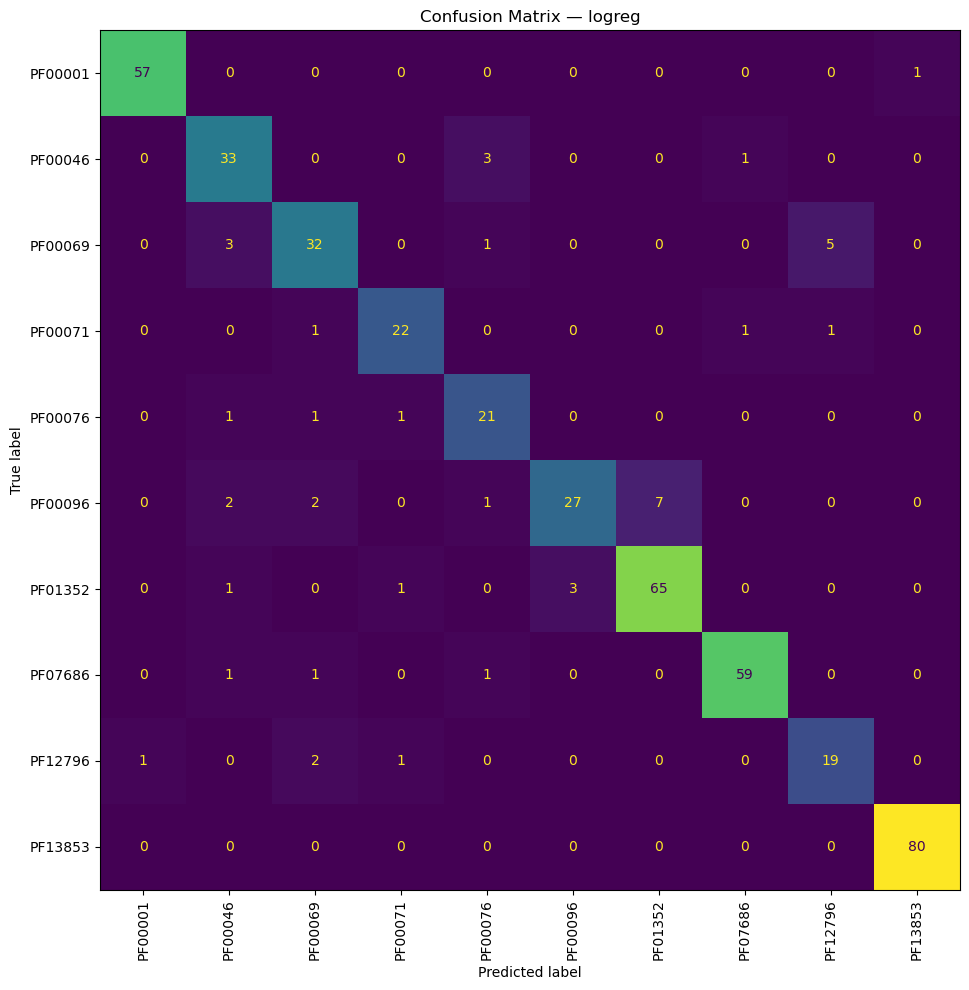


Training: linear_svm_calibrated
Saved model: /Users/saturnine/Projects/bio-seq-lm-capstone/models/protein/baselines/linear_svm_calibrated_top10_per400.pkl


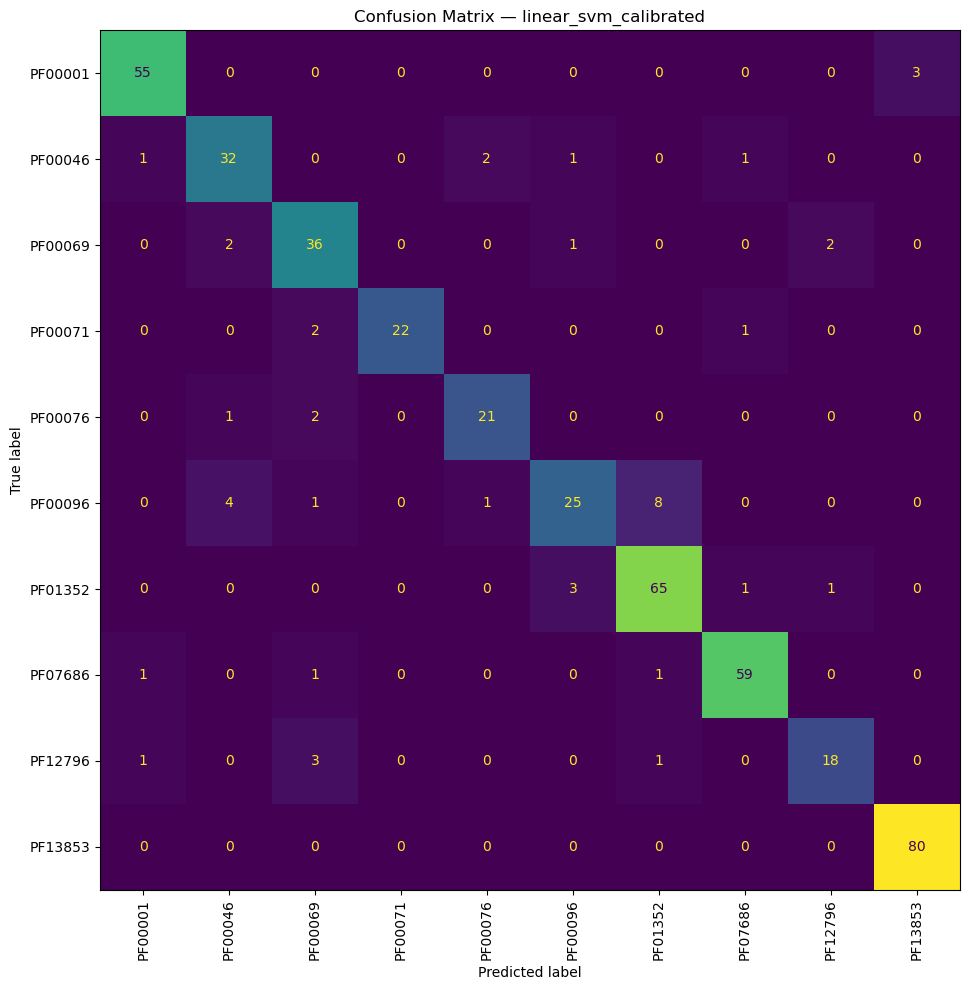


Training: random_forest
Saved model: /Users/saturnine/Projects/bio-seq-lm-capstone/models/protein/baselines/random_forest_top10_per400.pkl


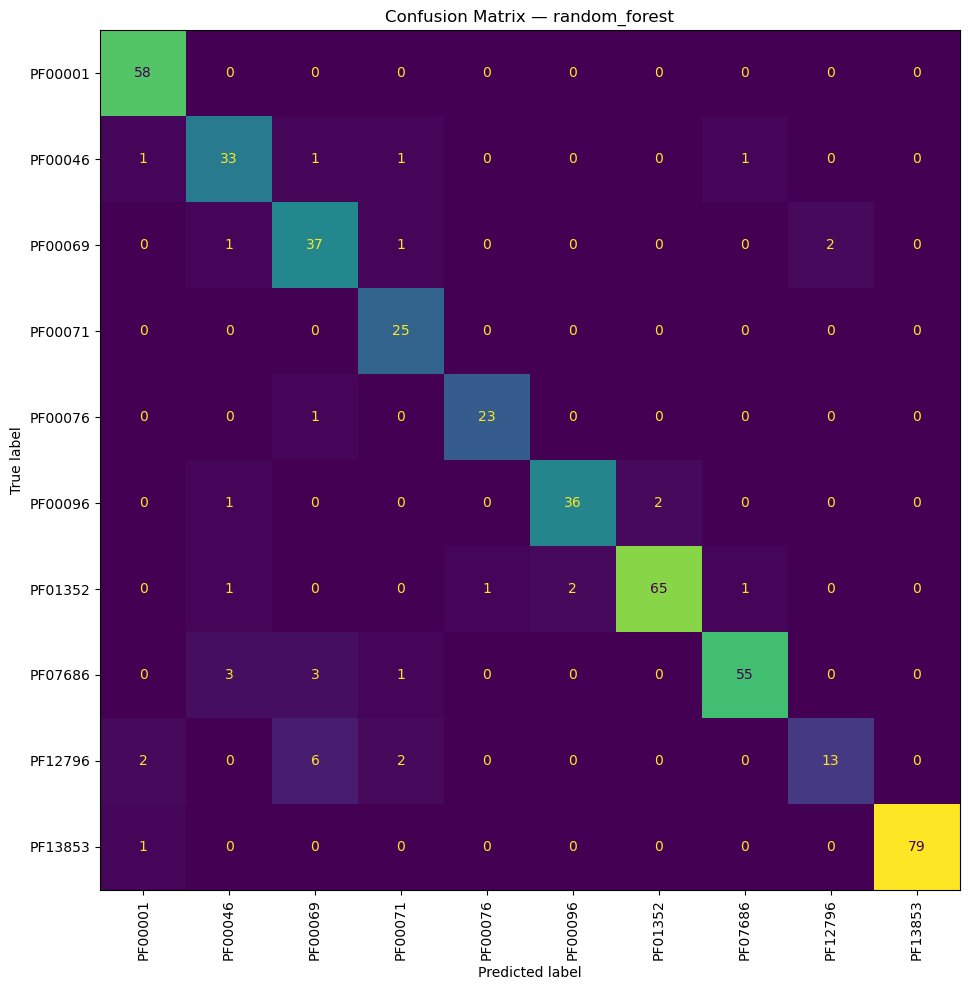


Training: grad_boost
Saved model: /Users/saturnine/Projects/bio-seq-lm-capstone/models/protein/baselines/grad_boost_top10_per400.pkl


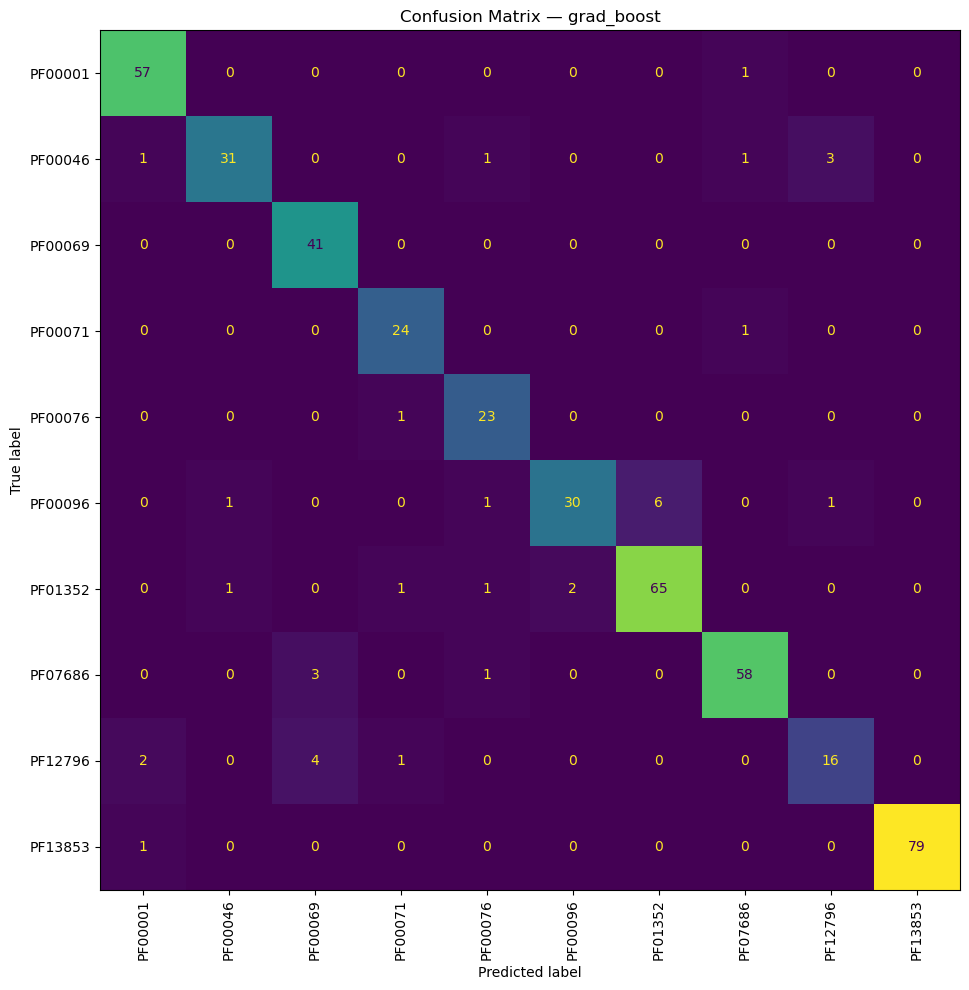


Training: xgboost
Saved model: /Users/saturnine/Projects/bio-seq-lm-capstone/models/protein/baselines/xgboost_top10_per400.pkl


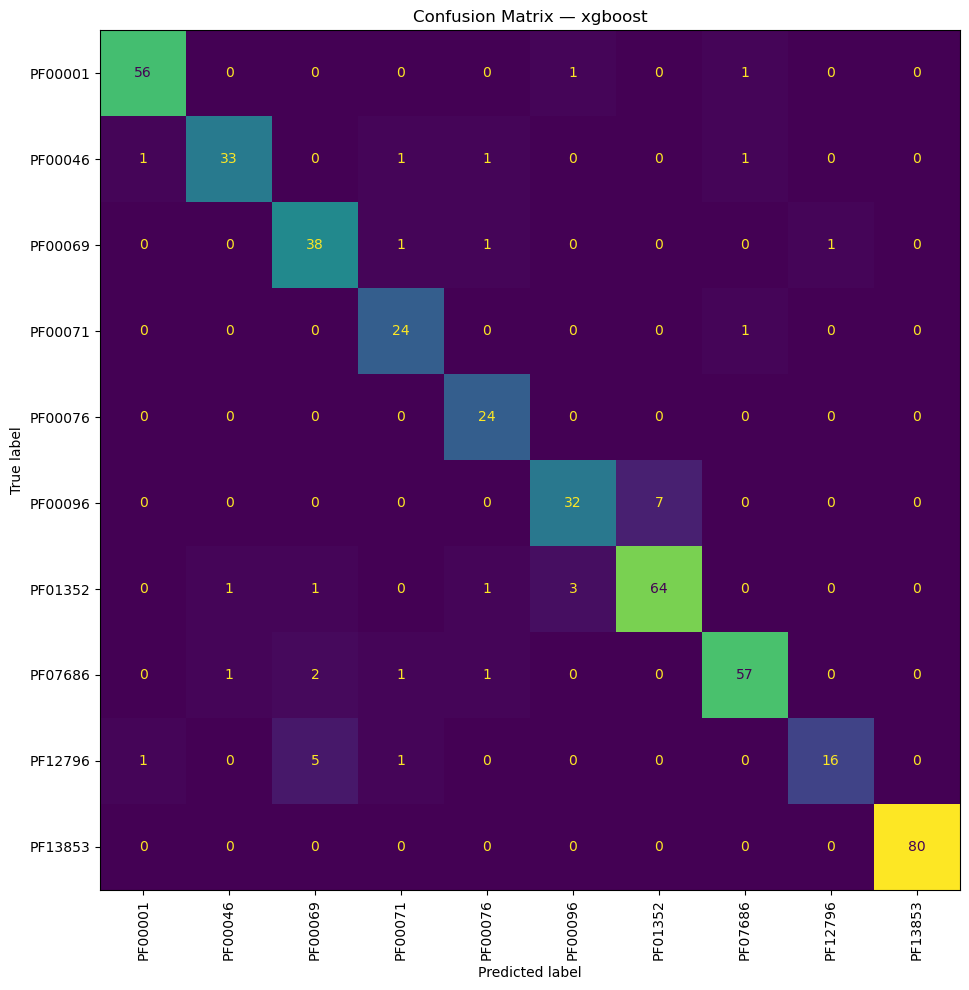

,accuracy,precision_w,recall_w,f1_w,n_test,model
0,0.923747,0.926073,0.923747,0.923069,459,xgboost
1,0.923747,0.927274,0.923747,0.922551,459,random_forest
2,0.923747,0.925141,0.923747,0.922473,459,grad_boost
3,0.904139,0.905974,0.904139,0.903420,459,logreg
4,0.899782,0.900105,0.899782,0.898155,459,linear_svm_calibrated


In [17]:
def evaluate_multiclass(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_w": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "recall_w": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "f1_w": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "n_test": int(len(y_true))
    }

test_rows = []
saved_models = {}
cm_paths = {}

for name, clf in models.items():
    print(f"\nTraining: {name}")
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    metrics = evaluate_multiclass(y_test, y_pred)
    metrics["model"] = name
    test_rows.append(metrics)

    model_path = MODELS_DIR / f"{name}_top{N_FAM}_per{PER_FAM}.pkl"
    joblib.dump(
        {
            "model": clf,
            "label_encoder": le,
            "n_families": N_FAM,
            "per_family": PER_FAM,
            "feature_dim": int(X.shape[1]),
            "seed": SEED
        },
        model_path
    )
    saved_models[name] = str(model_path)
    print("Saved model:", model_path)

    cm = confusion_matrix(y_test, y_pred, labels=np.arange(n_classes))
    plt.figure(figsize=(10, 10))
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(xticks_rotation=90, ax=plt.gca(), colorbar=False)
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()

    cm_path = FIGURES / f"cm_{name}_top{N_FAM}_per{PER_FAM}.png"
    plt.savefig(cm_path, dpi=200)
    plt.show()
    cm_paths[name] = str(cm_path)

test_df = pd.DataFrame(test_rows).sort_values("f1_w", ascending=False).reset_index(drop=True)
test_df

In [18]:
test_out = REPORTS / f"protein_baseline_test_results_top{N_FAM}_per{PER_FAM}.csv"
test_df.to_csv(test_out, index=False)
test_out

PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/protein_baseline_test_results_top10_per400.csv')

## Save a summary JSON for reporting

This is designed to be copyable directly into your project report later.

In [19]:
summary = {
    "task": "protein_pfam_family_classification",
    "feature_file": str(feat_path),
    "n_rows": int(df.shape[0]),
    "n_classes": int(n_classes),
    "classes": le.classes_.tolist(),
    "feature_dim": int(X.shape[1]),
    "train_size": int(X_train.shape[0]),
    "test_size": int(X_test.shape[0]),
    "cv_results_csv": str(cv_out),
    "test_results_csv": str(test_out),
    "models_dir": str(MODELS_DIR),
    "saved_models": saved_models,
    "confusion_matrices": cm_paths,
    "seed": int(SEED),
}

summary_path = REPORTS / f"protein_baseline_models_summary_top{N_FAM}_per{PER_FAM}.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

summary_path

PosixPath('/Users/saturnine/Projects/bio-seq-lm-capstone/reports/protein_baseline_models_summary_top10_per400.json')

## Interpretation checklist (quick)

When you run this notebook, confirm:
- CV results file is created under `reports/`
- Test results file is created under `reports/`
- Model `.pkl` files appear under `models/protein/baselines/`
- Confusion matrices appear under `reports/figures/`

If XGBoost still fails:
- confirm it is installed
- confirm `y` is integer-encoded (this notebook does it)
- confirm `objective="multi:softprob"` and `num_class=n_classes`